In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

In [2]:
breast_data=load_breast_cancer(as_frame=True)

full_df=breast_data.frame
feature_df=full_df.iloc[:,:-1]

scaled_features=StandardScaler().fit_transform(feature_df.values)
scaled_df=pd.DataFrame(scaled_features,columns=[f'Var_{i+1}' for i in range(scaled_features.shape[1])])

target=np.array(full_df.iloc[:,-1])

In [3]:
print(scaled_df.head())

      Var_1     Var_2     Var_3     Var_4     Var_5     Var_6     Var_7  \
0  1.097064 -2.073335  1.269934  0.984375  1.568466  3.283515  2.652874   
1  1.829821 -0.353632  1.685955  1.908708 -0.826962 -0.487072 -0.023846   
2  1.579888  0.456187  1.566503  1.558884  0.942210  1.052926  1.363478   
3 -0.768909  0.253732 -0.592687 -0.764464  3.283553  3.402909  1.915897   
4  1.750297 -1.151816  1.776573  1.826229  0.280372  0.539340  1.371011   

      Var_8     Var_9    Var_10  ...    Var_21    Var_22    Var_23    Var_24  \
0  2.532475  2.217515  2.255747  ...  1.886690 -1.359293  2.303601  2.001237   
1  0.548144  0.001392 -0.868652  ...  1.805927 -0.369203  1.535126  1.890489   
2  2.037231  0.939685 -0.398008  ...  1.511870 -0.023974  1.347475  1.456285   
3  1.451707  2.867383  4.910919  ... -0.281464  0.133984 -0.249939 -0.550021   
4  1.428493 -0.009560 -0.562450  ...  1.298575 -1.466770  1.338539  1.220724   

     Var_25    Var_26    Var_27    Var_28    Var_29    Var_30  
0  1

Cluster Labels:
 [1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 1 0 0 1 0 1 0 1 0
 0 1 0 1 1 0 0 1 1 1 0 1 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0
 0 1 0 0 0 0 1 1 0 0 1 1 0 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0
 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 0
 0 0 0 0 0 1 0 0 1 1 0 1 1 1 1 0 1 1 1 0 0 0 0 0 0 1 0 1 1 1 1 0 0 1 1 0 0
 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 0 1 0 1 1 1 0 1 1 1
 1 1 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 1 1 1 0 0
 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1
 1 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0
 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0

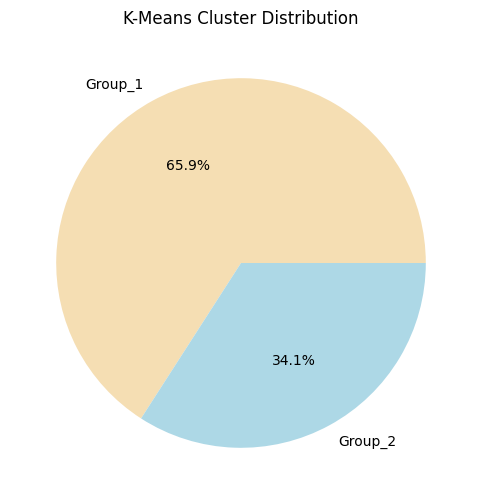

In [4]:
def Cluster_Method(dataset,num_clusters,max_iter=100,threshold=0.0004):

    matrix=np.array(dataset)

    total_rows,total_cols=matrix.shape

    iteration=1
    centroid_shift=1

    initial_rows=random.sample(range(total_rows),num_clusters)

    centers=matrix[initial_rows,:]

    while iteration<max_iter and centroid_shift>threshold:

        distance_matrix=np.zeros((total_rows,num_clusters))

        for cluster_no in range(num_clusters):

            distance_matrix[:,cluster_no]=np.linalg.norm(matrix-centers[cluster_no],axis=1)

        assigned_group=np.argmin(distance_matrix,axis=1)

        updated_centers=np.zeros((num_clusters,total_cols))

        for cluster_no in range(num_clusters):

            cluster_points=matrix[assigned_group==cluster_no]

            if len(cluster_points)>0:

                updated_centers[cluster_no]=np.mean(cluster_points,axis=0)

        centroid_shift=np.linalg.norm(updated_centers-centers)

        centers=updated_centers

        iteration+=1

    return assigned_group,centers,iteration


labels_a,centers_a,total_iter_a=Cluster_Method(scaled_df,2)

print("Cluster Labels:\n",labels_a)
print("Centroids:\n",centers_a)
print("Iterations:",total_iter_a)


cluster_freq=[0,0]

for value in labels_a:

    if value==0:
        cluster_freq[0]+=1
    else:
        cluster_freq[1]+=1


print("Cluster Counts:",cluster_freq)

plt.figure(figsize=(6,6))

plt.pie(
    cluster_freq,
    labels=["Group_1","Group_2"],
    autopct="%1.1f%%",
    colors=["wheat","lightblue"]
)

plt.title("K-Means Cluster Distribution")

plt.show()

Cluster Labels:
 [0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 0 1 0 0 1 1 0 1 0 1 0 1
 1 0 1 0 0 1 1 0 0 0 1 0 1 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1
 1 0 1 1 1 1 0 0 1 1 0 0 1 1 1 1 0 0 0 1 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 0 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1
 1 1 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 1 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 0 0 1 0 0 0
 0 0 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1

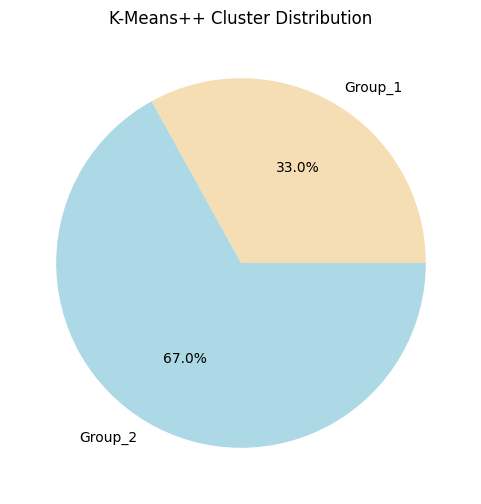

In [5]:
def Smart_Cluster_Method(dataset,num_clusters,max_iter=100,threshold=0.0004):

    matrix=np.array(dataset)

    total_rows,total_cols=matrix.shape

    iteration=1
    centroid_shift=1

    distance_vector=np.zeros(total_rows)

    seed_row=random.sample(range(total_rows),1)

    for row_no in range(total_rows):

        distance_vector[row_no]=np.linalg.norm(matrix[row_no,:]-matrix[seed_row,:])

    selected_rows=np.argpartition(distance_vector,num_clusters)[:num_clusters]

    centers=matrix[selected_rows,:]

    while iteration<max_iter and centroid_shift>threshold:

        distance_matrix=np.zeros((total_rows,num_clusters))

        for cluster_no in range(num_clusters):

            distance_matrix[:,cluster_no]=np.linalg.norm(matrix-centers[cluster_no],axis=1)

        assigned_group=np.argmin(distance_matrix,axis=1)

        updated_centers=np.zeros((num_clusters,total_cols))

        for cluster_no in range(num_clusters):

            cluster_points=matrix[assigned_group==cluster_no]
            

            if len(cluster_points)>0:

                updated_centers[cluster_no]=np.mean(cluster_points,axis=0)

        centroid_shift=np.linalg.norm(updated_centers-centers)        

        centers=updated_centers

        iteration+=1

    return assigned_group,centers,iteration


labels_b,centers_b,total_iter_b=Smart_Cluster_Method(scaled_df,2)

print("Cluster Labels:\n",labels_b)
print("Centroids:\n",centers_b)
print("Iterations:",total_iter_b)


cluster_freq2=[0,0]

for value in labels_b:

    if value==0:
        cluster_freq2[0]+=1
    else:
        cluster_freq2[1]+=1


print("Cluster Counts:",cluster_freq2)

plt.figure(figsize=(6,6))

plt.pie(
    cluster_freq2,
    labels=["Group_1","Group_2"],
    autopct="%1.1f%%",
    colors=["wheat","lightblue"]
)

plt.title("K-Means++ Cluster Distribution")

plt.show()